## Importación

In [ ]:
!pip install ydata-profiling

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_dolar = pd.read_excel("BCRD - Histórico diario de tasas.xlsx", header=8)
df_dolar

,Año,Mes,Día,Compra,Compra | Apre/depre acumulada (%),Compra | Apre/depre interanual (%),Venta,Venta | Apre/depre acumulada (%),Venta | Apre/depre interanual (%)
0,2026,7,17,58.2452,8.0,3.4,58.7316,7.8,3.3
1,2026,7,16,58.2420,8.0,3.4,58.5767,8.1,3.5
2,2026,7,15,58.1438,8.2,3.1,58.8184,7.6,3.1
3,2026,7,14,58.3569,7.8,3.0,58.8036,7.7,3.0
4,2026,7,13,58.3111,7.9,3.1,59.1185,7.1,2.5
...,...,...,...,...,...,...,...,...,...
1246,2021,7,26,56.9508,2.0,2.4,57.1987,2.0,2.1
1247,2021,7,23,57.0004,2.0,2.3,57.2017,2.0,2.1
1248,2021,7,22,56.9402,2.1,2.4,57.1850,2.0,2.1
1249,2021,7,21,56.9253,2.1,2.4,57.2268,1.9,2.0


In [ ]:
df_pib = pd.read_excel("pib_2018.xlsx", header=6)
df_pib

,Unnamed: 0,Índice,Variación porcentual interanual (%),Índice.1,Variación porcentual respecto al período anterior (%)
0,NaN,NaN,NaN,NaN,NaN
1,I,56.180015,NaN,56.136884,NaN
2,II,57.974939,NaN,56.731842,NaN
3,III,58.537013,NaN,60.283668,NaN
4,IV,60.824870,NaN,60.440998,NaN
...,...,...,...,...,...
94,IV,128.604066,1.900983,127.621850,0.114071
95,Promedio 2025 (p),126.914980,2.117391,NaN,NaN
96,I,132.627030,4.138639,130.944081,2.603183
97,Promedio 2026 (p),132.627030,4.138639,NaN,NaN


In [ ]:
df_ipc = pd.read_excel("ipc_base_2019-2020.xls", header=4)
df_ipc

,Período,Unnamed: 1,Indice,Variación Porcentual,Unnamed: 4,Unnamed: 5,Promedio,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,NaN,NaN,NaN,Mensual,con Dic.,12 meses,12 meses,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1984,Enero,1.379360,1.736466,1.736466,7.053607,5.570878,NaN,NaN,NaN,NaN
3,NaN,Febrero,1.418138,2.811245,4.596527,11.183496,6.007967,NaN,NaN,NaN,NaN
4,NaN,Marzo,1.435622,1.23291,5.886108,11.916329,6.516152,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
552,NaN,Mayo,139.248900,0.305421,1.496696,5.346102,4.436504,NaN,NaN,NaN,NaN
553,NaN,Junio,139.961300,0.511602,2.015955,5.666897,4.612239,NaN,NaN,NaN,NaN
554,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_tpm = pd.read_excel("Serie_TPM.xlsx", header=4)
df_tpm

,Año,Mes,Tasa de Política Monetaria,Facilidades Permanentes,Unnamed: 4,Unnamed: 5
0,NaN,NaN,NaN,Depósito,Préstamo,Lombarda
1,2004,Ene,0.4500,0.45,NaN,0.55
2,NaN,Feb,0.5000,0.5,NaN,0.6
3,NaN,Mar,0.5000,0.5,NaN,0.6
4,NaN,Abr,0.5000,0.5,NaN,0.6
...,...,...,...,...,...,...
269,NaN,May,0.0525,0.045,0.0575,NaN
270,NaN,Jun,0.0525,0.045,0.0575,NaN
271,NaN,Jul,0.0525,0.045,0.0575,NaN
272,1A partir de febrero de 2013 se introdujo un n...,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_petroleo = pd.read_csv("crude_oil_brent.csv")
df_petroleo

,Date,Price,Year,Month,Day
0,2026-06-01,98.29,2026,6,1
1,2026-05-29,92.88,2026,5,29
2,2026-05-28,95.47,2026,5,28
3,2026-05-27,97.11,2026,5,27
4,2026-05-26,102.75,2026,5,26
...,...,...,...,...,...
9897,1987-05-26,18.63,1987,5,26
9898,1987-05-25,18.60,1987,5,25
9899,1987-05-22,18.55,1987,5,22
9900,1987-05-21,18.45,1987,5,21


## Cleaning & Merging

In [ ]:
# Convert Año	Mes	Día to single column fecha
df_dolar["fecha"] = df_dolar["Año"].astype(str) + "-" + df_dolar["Mes"].astype(str) + "-" + df_dolar["Día"].astype(str)
df_dolar["fecha"] = pd.to_datetime(df_dolar["fecha"])
df_dolar = df_dolar.rename(columns={"Compra": "compra_dolar", "Venta": "venta_dolar"})
df_dolar = df_dolar[["fecha", "compra_dolar", "venta_dolar"]]
df_dolar

,fecha,compra_dolar,venta_dolar
0,2026-07-17,58.2452,58.7316
1,2026-07-16,58.2420,58.5767
2,2026-07-15,58.1438,58.8184
3,2026-07-14,58.3569,58.8036
4,2026-07-13,58.3111,59.1185
...,...,...,...
1246,2021-07-26,56.9508,57.1987
1247,2021-07-23,57.0004,57.2017
1248,2021-07-22,56.9402,57.1850
1249,2021-07-21,56.9253,57.2268


In [ ]:
df_petroleo = df_petroleo.rename(columns={"Date": "fecha", "Price": "precio_petroleo"})
df_petroleo["fecha"] = pd.to_datetime(df_petroleo["fecha"])
df_petroleo = df_petroleo[["fecha", "precio_petroleo"]]
df_petroleo

,fecha,precio_petroleo
0,2026-06-01,98.29
1,2026-05-29,92.88
2,2026-05-28,95.47
3,2026-05-27,97.11
4,2026-05-26,102.75
...,...,...
9897,1987-05-26,18.63
9898,1987-05-25,18.60
9899,1987-05-22,18.55
9900,1987-05-21,18.45


In [ ]:
def extract_year_pib(x):
  data = x.split()
  if data[0] != "Promedio": return None
  if len(data) > 1: return int(data[1])
  return None

def extract_trimester_pib(x):
  if "Promedio" in x: return None
  # Convert I, II, III, IV into fecha_trimestre
  if x == "I": return 1
  if x == "II": return 2
  if x == "III": return 3
  if x == "IV": return 4

df_pib = df_pib.dropna(subset=["Índice"])
df_pib["Año"] = df_pib["Unnamed: 0"].apply(extract_year_pib)
df_pib.loc[1, "Año"] = 2006
df_pib["Año"] = df_pib["Año"].ffill().astype(int)
df_pib["Trimestre"] = df_pib["Unnamed: 0"].apply(extract_trimester_pib)

df_pib = df_pib.dropna(subset=["Trimestre"])
df_pib["Trimestre"] = df_pib["Trimestre"].astype(int)
# Convert year-trimester to date
df_pib["Mes"] = (df_pib["Trimestre"] - 1) * 3 + 1
df_pib["fecha"] = pd.to_datetime(df_pib["Año"].astype(str) + "-" + df_pib["Mes"].astype(str))
df_pib = df_pib.rename(columns={"Índice": "indice_pib"})
df_pib = df_pib[["fecha", "indice_pib"]]
df_pib

/tmp/ipykernel_945/2036715462.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pib["Año"] = df_pib["Unnamed: 0"].apply(extract_year_pib)
/tmp/ipykernel_945/2036715462.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pib["Año"] = df_pib["Año"].ffill().astype(int)
/tmp/ipykernel_945/2036715462.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

,fecha,indice_pib
1,2006-01-01,56.180015
2,2006-04-01,57.974939
3,2006-07-01,58.537013
4,2006-10-01,60.824870
6,2007-01-01,60.995955
...,...,...
91,2024-01-01,127.356216
92,2024-04-01,126.853658
93,2024-07-01,124.845980
94,2024-10-01,128.604066


In [ ]:
def convert_mes_to_int(x):
  if "Ene" in x: return 1
  if "Feb" in x: return 2
  if "Mar" in x: return 3
  if "Abr" in x: return 4
  if "May" in x: return 5
  if "Jun" in x: return 6
  if "Jul" in x: return 7
  if "Ago" in x: return 8
  if "Sep" in x: return 9
  if "Oct" in x: return 10
  if "Nov" in x: return 11
  if "Dic" in x: return 12
  return None

df_tpm = df_tpm.dropna(subset=["Mes"])
df_tpm["Mes"] = df_tpm["Mes"].apply(convert_mes_to_int)
df_tpm["Año"] = df_tpm["Año"].ffill()
df_tpm["fecha"] = pd.to_datetime(df_tpm["Año"].astype(str) + "-" + df_tpm["Mes"].astype(str))
df_tpm = df_tpm.rename(columns={"Tasa de Política Monetaria": "tpm"})
df_tpm = df_tpm[["fecha", "tpm"]]
df_tpm

/tmp/ipykernel_945/3325125945.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tpm["Mes"] = df_tpm["Mes"].apply(convert_mes_to_int)
/tmp/ipykernel_945/3325125945.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_tpm["Año"] = df_tpm["Año"].ffill()
/tmp/ipykernel_945/3325125945.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gu

,fecha,tpm
1,2004-01-01,0.4500
2,2004-02-01,0.5000
3,2004-03-01,0.5000
4,2004-04-01,0.5000
5,2004-05-01,0.1500
...,...,...
267,2026-03-01,0.0525
268,2026-04-01,0.0525
269,2026-05-01,0.0525
270,2026-06-01,0.0525


In [ ]:
df_ipc = df_ipc.dropna(subset=["Unnamed: 1"])
df_ipc["Unnamed: 1"] = df_ipc["Unnamed: 1"].apply(convert_mes_to_int)
df_ipc["Período"] = df_ipc["Período"].apply(lambda x: None if x == " " else x)
df_ipc["Período"] = df_ipc["Período"].ffill()
df_ipc["fecha"] = pd.to_datetime(df_ipc["Período"].astype(str) + "-" + df_ipc["Unnamed: 1"].astype(str))
df_ipc = df_ipc.rename(columns={"Indice": "ipc"})
df_ipc = df_ipc[["fecha", "ipc"]]
df_ipc

/tmp/ipykernel_945/957751545.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ipc["Unnamed: 1"] = df_ipc["Unnamed: 1"].apply(convert_mes_to_int)
/tmp/ipykernel_945/957751545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ipc["Período"] = df_ipc["Período"].apply(lambda x: None if x == " " else x)
/tmp/ipykernel_945/957751545.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

,fecha,ipc
2,1984-01-01,1.379360
3,1984-02-01,1.418138
4,1984-03-01,1.435622
5,1984-04-01,1.458127
6,1984-05-01,1.475611
...,...,...
549,2026-02-01,137.774400
550,2026-03-01,138.149500
551,2026-04-01,138.824900
552,2026-05-01,139.248900


In [ ]:
# Create master date table from 1984 to July 2006
df_master = pd.DataFrame(pd.date_range(
      start="1984-01-01",
      end="2026-07-01"
  ), columns=["fecha"])

df_master = df_master.merge(df_dolar, on="fecha", how="left")
df_master = df_master.merge(df_pib, on="fecha", how="left")
df_master = df_master.merge(df_ipc, on="fecha", how="left")
df_master = df_master.merge(df_tpm, on="fecha", how="left")
df_master = df_master.merge(df_petroleo, on="fecha", how="left")

#df_master.iloc[:, 1:] = df_master.iloc[:, 1:].ffill()
df_master

,fecha,compra_dolar,venta_dolar,indice_pib,ipc,tpm,precio_petroleo
0,1984-01-01,NaN,NaN,NaN,1.37936,NaN,NaN
1,1984-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2,1984-01-03,NaN,NaN,NaN,NaN,NaN,NaN
3,1984-01-04,NaN,NaN,NaN,NaN,NaN,NaN
4,1984-01-05,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
15518,2026-06-27,NaN,NaN,NaN,NaN,NaN,NaN
15519,2026-06-28,NaN,NaN,NaN,NaN,NaN,NaN
15520,2026-06-29,59.1917,60.2018,NaN,NaN,NaN,NaN
15521,2026-06-30,59.2684,59.9442,NaN,NaN,NaN,NaN


## EDA & Feature Engineering

In [ ]:
# See date ranges per non-nan columns
date_ranges_per_column = []
for col in df_master.columns[1:]:
  date_ranges_per_column.append(pd.Series({
      "col": col,
      "min_date": df_master[df_master[col].notna()]["fecha"].min(),
      "max_date": df_master[df_master[col].notna()]["fecha"].max()
  }))

pd.DataFrame(date_ranges_per_column)

,col,min_date,max_date
0,compra_dolar,2021-07-20,2026-07-01
1,venta_dolar,2021-07-20,2026-07-01
2,indice_pib,2006-01-01,2025-01-01
3,ipc,1984-01-01,2026-06-01
4,tpm,2004-01-01,2026-07-01
5,precio_petroleo,1987-05-20,2026-06-01


In [ ]:
# Se usará data del Aug 2021 a Aug 2025 despues de ffill
df_master.iloc[:, 1:] = df_master.iloc[:, 1:].ffill()
df_master = df_master[(df_master["fecha"] >= "2021-08-01") & (df_master["fecha"] <= "2025-08-01")]
df_master

,fecha,compra_dolar,venta_dolar,indice_pib,ipc,tpm,precio_petroleo
13727,2021-08-01,56.9927,57.2182,113.210647,110.0390,0.0300,77.72
13728,2021-08-02,56.9622,57.2257,113.210647,110.0390,0.0300,73.91
13729,2021-08-03,56.9852,57.2347,113.210647,110.0390,0.0300,73.24
13730,2021-08-04,57.0297,57.2304,113.210647,110.0390,0.0300,70.99
13731,2021-08-05,57.0031,57.2250,113.210647,110.0390,0.0300,72.14
...,...,...,...,...,...,...,...
15184,2025-07-28,60.7501,61.1515,132.627030,132.9548,0.0575,70.87
15185,2025-07-29,60.7281,61.0940,132.627030,132.9548,0.0575,73.21
15186,2025-07-30,60.5928,61.1195,132.627030,132.9548,0.0575,73.98
15187,2025-07-31,60.5350,61.1961,132.627030,132.9548,0.0575,73.43


In [ ]:
df_master.describe()

,fecha,compra_dolar,venta_dolar,indice_pib,ipc,tpm,precio_petroleo
count,1462,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000
mean,2023-08-01 12:00:00,57.208856,57.531335,123.871759,123.746932,0.065150,84.449822
min,2021-08-01 00:00:00,52.779000,53.162800,113.210647,110.039000,0.030000,60.310000
25%,2022-08-01 06:00:00,54.994875,55.282900,118.627061,119.718000,0.057500,75.190000
50%,2023-08-01 12:00:00,56.713350,56.978050,124.388213,124.828200,0.070000,82.045000
75%,2024-07-31 18:00:00,58.961800,59.301375,127.356216,128.972350,0.077500,88.930000
max,2025-08-01 00:00:00,63.087300,63.485300,132.627030,133.896500,0.085000,133.180000
std,NaN,2.391307,2.404434,5.400283,6.321828,0.015718,13.099381


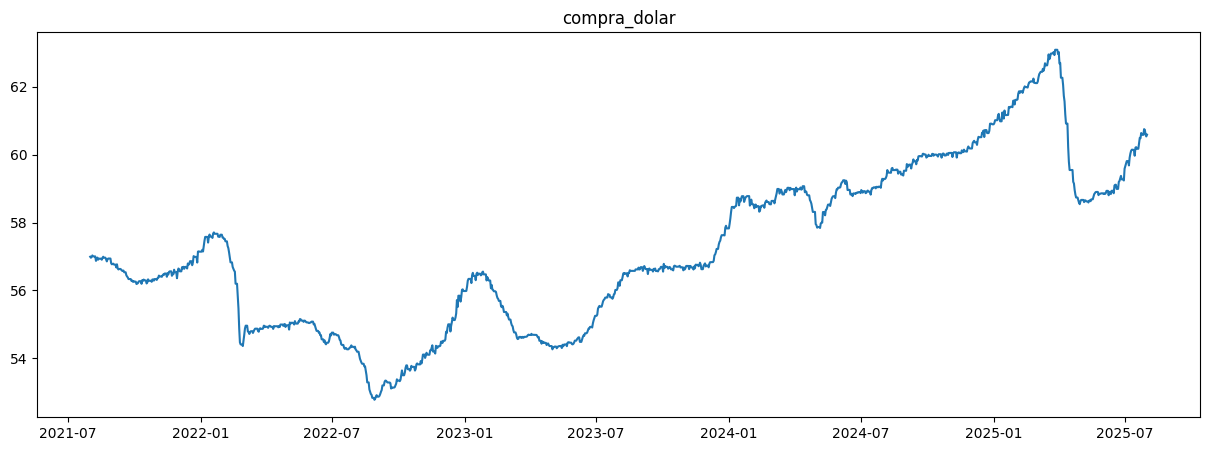

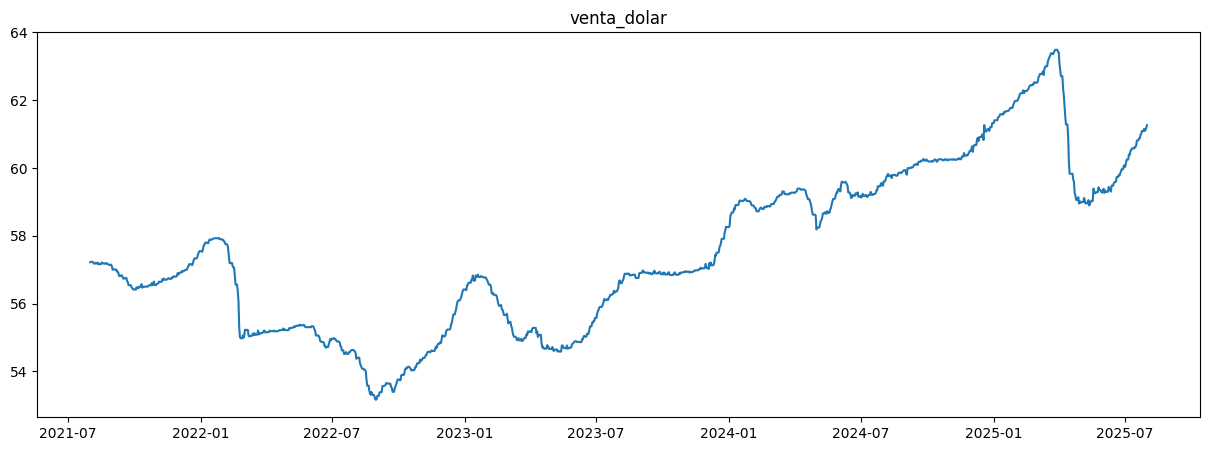

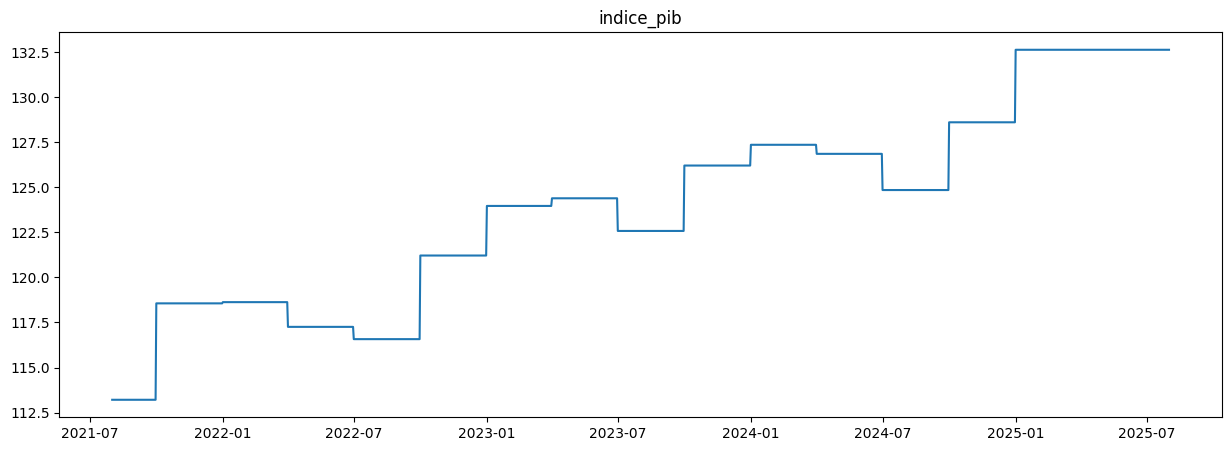

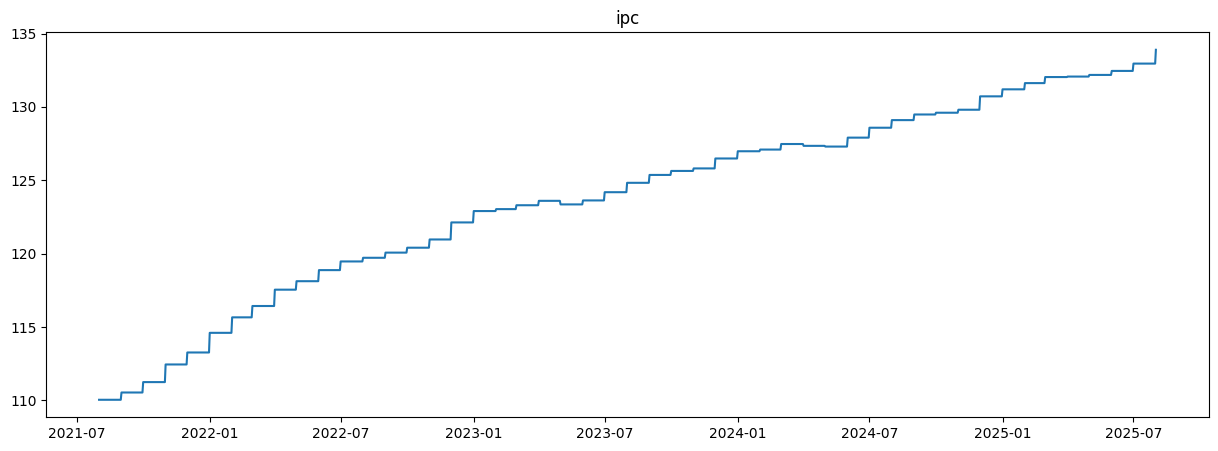

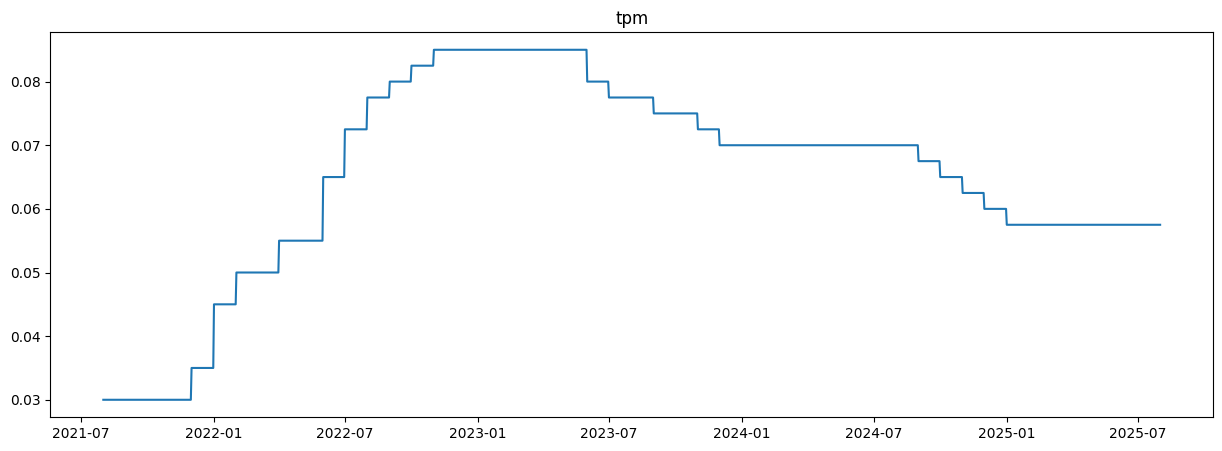

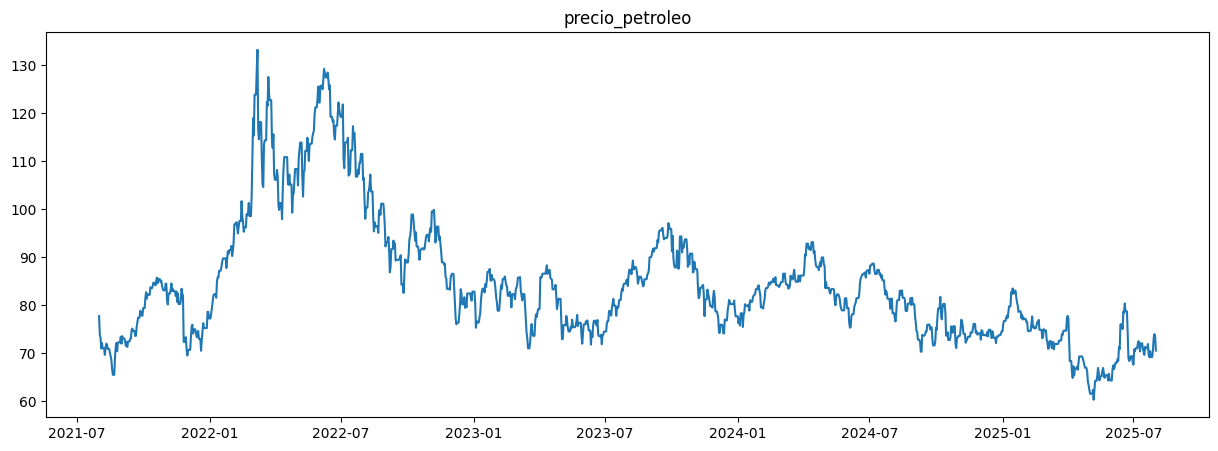

In [ ]:
# Graph each variable by time
for col in df_master.columns[1:]:
  plt.figure(figsize=(15, 5))
  plt.plot(df_master["fecha"], df_master[col])
  plt.title(col)
  plt.show()

In [ ]:
# Define target as variation
df_master = df_master.copy()
df_master = df_master.sort_values("fecha").reset_index(drop=True)

df_master["target"] = df_master["compra_dolar"].pct_change().shift(-1)
df_master[["target"]].describe().T

,count,mean,std,min,25%,50%,75%,max
target,1461.0,0.000043,0.001423,-0.01137,-0.000398,0.0,0.000546,0.007035


In [ ]:
# Create lag features
for lag in [1, 2, 3, 7, 15, 30]:
    df_master[f"usd_lag_{lag}"] = df_master["compra_dolar"].pct_change(lag)

# Create rolling features
for w in [7, 15, 30]:
    returns = df_master["compra_dolar"].pct_change()

    df_master[f"usd_mean_return_{w}"] = returns.rolling(w).mean()
    df_master[f"usd_std_return_{w}"] = returns.rolling(w).std()
    df_master[f"usd_min_return_{w}"] = returns.rolling(w).min()
    df_master[f"usd_max_return_{w}"] = returns.rolling(w).max()

# Create momentum variables
for m in [7, 15, 30]:
  df_master[f"usd_momentum_{m}"] = (
      df_master["compra_dolar"] /
      df_master["compra_dolar"].shift(m)
      - 1
  )

df_master.iloc[:, 8:]

,usd_lag_1,usd_lag_2,usd_lag_3,usd_lag_7,usd_lag_15,usd_lag_30,usd_mean_return_7,usd_std_return_7,usd_min_return_7,usd_max_return_7,...,usd_std_return_15,usd_min_return_15,usd_max_return_15,usd_mean_return_30,usd_std_return_30,usd_min_return_30,usd_max_return_30,usd_momentum_7,usd_momentum_15,usd_momentum_30
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-0.000535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.000404,-0.000132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.000781,0.001185,0.000649,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-0.000466,0.000314,0.000718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1457,0.002770,0.002770,0.002770,0.006828,0.010079,0.024951,0.000974,0.001574,-0.000889,0.00277,...,0.001798,-0.002507,0.003962,0.000823,0.001824,-0.002507,0.005865,0.006828,0.010079,0.024951
1458,-0.000362,0.002407,0.002407,0.003880,0.010152,0.024580,0.000554,0.001464,-0.000889,0.00277,...,0.001795,-0.002507,0.003962,0.000811,0.001830,-0.002507,0.005865,0.003880,0.010152,0.024580
1459,-0.002228,-0.002589,0.000173,0.001810,0.010434,0.022877,0.000260,0.001802,-0.002228,0.00277,...,0.001761,-0.002228,0.003962,0.000756,0.001897,-0.002507,0.005865,0.001810,0.010434,0.022877
1460,-0.000954,-0.003180,-0.003541,-0.001669,0.005486,0.015944,-0.000238,0.001531,-0.002228,0.00277,...,0.001554,-0.002228,0.002770,0.000529,0.001658,-0.002507,0.003962,-0.001669,0.005486,0.015944


In [ ]:
# Create features with other variables

variables = [
    "indice_pib",
    "ipc",
    "tpm",
    "precio_petroleo"
]

for col in variables:

    # percentage variation
    df_master[f"{col}_chg_1"] = df_master[col].pct_change()

    # multi variations
    df_master[f"{col}_chg_7"] = df_master[col].pct_change(7)
    df_master[f"{col}_chg_15"] = df_master[col].pct_change(15)
    df_master[f"{col}_chg_30"] = df_master[col].pct_change(30)

    # acceleration
    df_master[f"{col}_accel"] = df_master[f"{col}_chg_1"].diff()

    # rolling averages of variation
    df_master[f"{col}_rolling7"] = (
        df_master[f"{col}_chg_1"]
        .rolling(7)
        .mean()
    )
df_master.iloc[:, 29:]

,indice_pib_chg_1,indice_pib_chg_7,indice_pib_chg_15,indice_pib_chg_30,indice_pib_accel,indice_pib_rolling7,ipc_chg_1,ipc_chg_7,ipc_chg_15,ipc_chg_30,...,tpm_chg_15,tpm_chg_30,tpm_accel,tpm_rolling7,precio_petroleo_chg_1,precio_petroleo_chg_7,precio_petroleo_chg_15,precio_petroleo_chg_30,precio_petroleo_accel,precio_petroleo_rolling7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.049022,NaN,NaN,NaN,NaN,NaN
2,0.0,NaN,NaN,NaN,0.0,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,-0.009065,NaN,NaN,NaN,0.039957,NaN
3,0.0,NaN,NaN,NaN,0.0,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,-0.030721,NaN,NaN,NaN,-0.021656,NaN
4,0.0,NaN,NaN,NaN,0.0,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,0.016199,NaN,NaN,NaN,0.046920,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1457,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.003772,...,0.0,0.0,0.0,0.0,0.023689,-0.014600,-0.016514,0.021623,0.023689,-0.001944
1458,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.003772,...,0.0,0.0,0.0,0.0,0.033018,0.050509,0.031708,0.055355,0.009329,0.007203
1459,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.003772,...,0.0,0.0,0.0,0.0,0.010518,0.069539,0.052796,0.085547,-0.022501,0.009771
1460,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,-0.007434,0.042744,0.053969,0.085761,-0.017952,0.006127


In [ ]:
# Finally, calendar features
df_master["month"] = df_master["fecha"].dt.month
df_master["quarter"] = df_master["fecha"].dt.quarter

# cyclical encoding
df_master["month_sin"] = np.sin(2*np.pi*df_master["month"]/12)
df_master["month_cos"] = np.cos(2*np.pi*df_master["month"]/12)

df_master = df_master.dropna().reset_index(drop=True)
df_master

,fecha,compra_dolar,venta_dolar,indice_pib,ipc,tpm,precio_petroleo,target,usd_lag_1,usd_lag_2,...,precio_petroleo_chg_1,precio_petroleo_chg_7,precio_petroleo_chg_15,precio_petroleo_chg_30,precio_petroleo_accel,precio_petroleo_rolling7,month,quarter,month_sin,month_cos
0,2021-08-31,56.7688,57.0953,113.210647,110.0390,0.0300,73.45,0.000220,-0.000548,-0.002980,...,0.016468,0.031456,0.048237,-0.054941,0.016468,0.004544,8,3,-0.866025,-5.000000e-01
1,2021-09-01,56.7813,57.0004,113.210647,110.5350,0.0300,71.99,0.000093,0.000220,-0.000327,...,-0.019877,-0.001803,0.037320,-0.025978,-0.036346,-0.000122,9,3,-1.000000,-1.836970e-16
2,2021-09-02,56.7866,57.0157,113.210647,110.5350,0.0300,73.56,-0.000479,0.000093,0.000314,...,0.021809,0.044590,0.072147,0.004369,0.041686,0.006361,9,3,-1.000000,-1.836970e-16
3,2021-09-03,56.7594,57.0041,113.210647,110.5350,0.0300,73.07,0.000000,-0.000479,-0.000386,...,-0.006661,0.011210,0.093862,0.029300,-0.028470,0.001677,9,3,-1.000000,-1.836970e-16
4,2021-09-04,56.7594,57.0041,113.210647,110.5350,0.0300,73.07,0.000000,0.000000,-0.000479,...,0.000000,0.011210,0.115402,0.012892,0.006661,0.001677,9,3,-1.000000,-1.836970e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1426,2025-07-27,60.5823,61.0887,132.627030,132.9548,0.0575,69.23,0.002770,0.000000,0.000000,...,0.000000,-0.025753,-0.039273,-0.002018,0.000000,-0.003599,7,3,-0.500000,-8.660254e-01
1427,2025-07-28,60.7501,61.1515,132.627030,132.9548,0.0575,70.87,-0.000362,0.002770,0.002770,...,0.023689,-0.014600,-0.016514,0.021623,0.023689,-0.001944,7,3,-0.500000,-8.660254e-01
1428,2025-07-29,60.7281,61.0940,132.627030,132.9548,0.0575,73.21,-0.002228,-0.000362,0.002407,...,0.033018,0.050509,0.031708,0.055355,0.009329,0.007203,7,3,-0.500000,-8.660254e-01
1429,2025-07-30,60.5928,61.1195,132.627030,132.9548,0.0575,73.98,-0.000954,-0.002228,-0.002589,...,0.010518,0.069539,0.052796,0.085547,-0.022501,0.009771,7,3,-0.500000,-8.660254e-01


In [ ]:
# Select final features
df_feats = df_master[['fecha', 'indice_pib', 'ipc', 'tpm',
       'precio_petroleo', 'usd_lag_1', 'usd_lag_2', 'usd_lag_3',
       'usd_lag_7', 'usd_lag_15', 'usd_lag_30', 'usd_mean_return_7',
       'usd_std_return_7', 'usd_min_return_7', 'usd_max_return_7',
       'usd_mean_return_15', 'usd_std_return_15', 'usd_min_return_15',
       'usd_max_return_15', 'usd_mean_return_30', 'usd_std_return_30',
       'usd_min_return_30', 'usd_max_return_30', 'usd_momentum_7',
       'usd_momentum_15', 'usd_momentum_30', 'indice_pib_chg_1',
       'indice_pib_chg_7', 'indice_pib_chg_15', 'indice_pib_chg_30',
       'indice_pib_accel', 'indice_pib_rolling7', 'ipc_chg_1', 'ipc_chg_7',
       'ipc_chg_15', 'ipc_chg_30', 'ipc_accel', 'ipc_rolling7', 'tpm_chg_1',
       'tpm_chg_7', 'tpm_chg_15', 'tpm_chg_30', 'tpm_accel', 'tpm_rolling7',
       'precio_petroleo_chg_1', 'precio_petroleo_chg_7',
       'precio_petroleo_chg_15', 'precio_petroleo_chg_30',
       'precio_petroleo_accel', 'precio_petroleo_rolling7', 'quarter',
       'month_sin', 'month_cos', 'target']]

df_feats = df_feats.set_index(df_master["fecha"])
df_feats = df_feats.drop(columns=["fecha"])
df_feats

,indice_pib,ipc,tpm,precio_petroleo,usd_lag_1,usd_lag_2,usd_lag_3,usd_lag_7,usd_lag_15,usd_lag_30,...,precio_petroleo_chg_1,precio_petroleo_chg_7,precio_petroleo_chg_15,precio_petroleo_chg_30,precio_petroleo_accel,precio_petroleo_rolling7,quarter,month_sin,month_cos,target
fecha,,,,,,,,,,,,,,,,,,,,,
2021-08-31,113.210647,110.0390,0.0300,73.45,-0.000548,-0.002980,-0.002980,-0.001514,-0.002916,-0.003929,...,0.016468,0.031456,0.048237,-0.054941,0.016468,0.004544,3,-0.866025,-5.000000e-01,0.000220
2021-09-01,113.210647,110.5350,0.0300,71.99,0.000220,-0.000327,-0.002761,-0.002453,-0.002163,-0.003176,...,-0.019877,-0.001803,0.037320,-0.025978,-0.036346,-0.000122,3,-1.000000,-1.836970e-16,0.000093
2021-09-02,113.210647,110.5350,0.0300,73.56,0.000093,0.000314,-0.000234,-0.002691,-0.002967,-0.003485,...,0.021809,0.044590,0.072147,0.004369,0.041686,0.006361,3,-1.000000,-1.836970e-16,-0.000479
2021-09-03,113.210647,110.5350,0.0300,73.07,-0.000479,-0.000386,-0.000166,-0.003145,-0.004069,-0.004740,...,-0.006661,0.011210,0.093862,0.029300,-0.028470,0.001677,3,-1.000000,-1.836970e-16,0.000000
2021-09-04,113.210647,110.5350,0.0300,73.07,0.000000,-0.000479,-0.000386,-0.003145,-0.003590,-0.004275,...,0.000000,0.011210,0.115402,0.012892,0.006661,0.001677,3,-1.000000,-1.836970e-16,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-27,132.627030,132.9548,0.0575,69.23,0.000000,0.000000,-0.000889,0.006820,0.007289,0.022120,...,0.000000,-0.025753,-0.039273,-0.002018,0.000000,-0.003599,3,-0.500000,-8.660254e-01,0.002770
2025-07-28,132.627030,132.9548,0.0575,70.87,0.002770,0.002770,0.002770,0.006828,0.010079,0.024951,...,0.023689,-0.014600,-0.016514,0.021623,0.023689,-0.001944,3,-0.500000,-8.660254e-01,-0.000362
2025-07-29,132.627030,132.9548,0.0575,73.21,-0.000362,0.002407,0.002407,0.003880,0.010152,0.024580,...,0.033018,0.050509,0.031708,0.055355,0.009329,0.007203,3,-0.500000,-8.660254e-01,-0.002228


## Training

In [ ]:
X, y = df_feats.drop(columns=["target"]), df_feats["target"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000380 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6759
[LightGBM] [Info] Number of data points in the train set: 1144, number of used features: 48
[LightGBM] [Info] Start training from score 0.000049
MSE: 2.96744911974803e-06
MAE: 0.0010939667389761002
R2: 0.043403601618636656


In [ ]:
# Calcular accuracy direccional alza o baja
y_pred_dir = np.where(y_pred > 0, 1, 0)
y_test_dir = np.where(y_test > 0, 1, 0)
accuracy = np.mean(y_pred_dir == y_test_dir)
print("Direction accuracy:", accuracy)

Direction accuracy: 0.5505226480836237


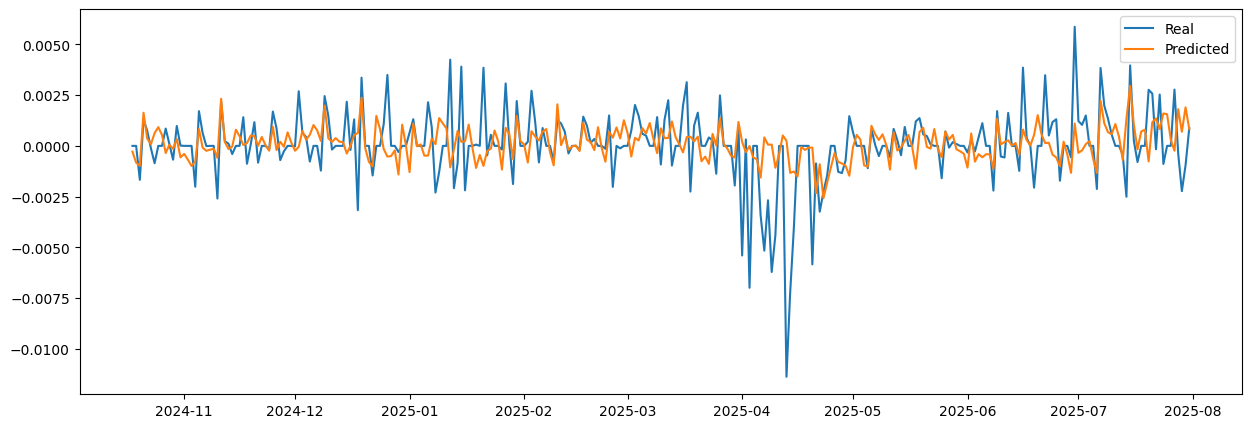

In [ ]:
# Graph Precited vs Real
plt.figure(figsize=(15, 5))
plt.plot(y_test.index, y_test.values, label="Real")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.legend()
plt.show()

In [ ]:
# See variable importances
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)
importances

,feature,importance
6,usd_lag_3,218
5,usd_lag_2,206
9,usd_lag_30,175
4,usd_lag_1,173
15,usd_std_return_15,173
7,usd_lag_7,170
45,precio_petroleo_chg_15,150
8,usd_lag_15,142
12,usd_min_return_7,131
19,usd_std_return_30,128


In [ ]:
# Filter variables that capture 80% of importance
total_importance = importances.importance.sum()
importances["acc_importance"] = importances.importance.cumsum() / total_importance
most_important_features = importances[importances.acc_importance <= 0.8]
most_important_features

,feature,importance,acc_importance
6,usd_lag_3,218,0.072667
5,usd_lag_2,206,0.141333
9,usd_lag_30,175,0.199667
4,usd_lag_1,173,0.257333
15,usd_std_return_15,173,0.315000
7,usd_lag_7,170,0.371667
45,precio_petroleo_chg_15,150,0.421667
8,usd_lag_15,142,0.469000
12,usd_min_return_7,131,0.512667
19,usd_std_return_30,128,0.555333


## Retraining

In [ ]:
# Retrain model only using best features
model = LGBMRegressor(random_state=42)
model.fit(X_train[most_important_features.feature], y_train)

y_pred = model.predict(X_test[most_important_features.feature])
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4013
[LightGBM] [Info] Number of data points in the train set: 1144, number of used features: 16
[LightGBM] [Info] Start training from score 0.000049
MSE: 2.842706471250784e-06
MAE: 0.0010835596511737835
R2: 0.08361604114553578


In [ ]:
# Calcular accuracy direccional alza o baja
y_pred_dir = np.where(y_pred > 0, 1, 0)
y_test_dir = np.where(y_test > 0, 1, 0)
accuracy = np.mean(y_pred_dir == y_test_dir)
print("Direction accuracy:", accuracy)

Direction accuracy: 0.5435540069686411


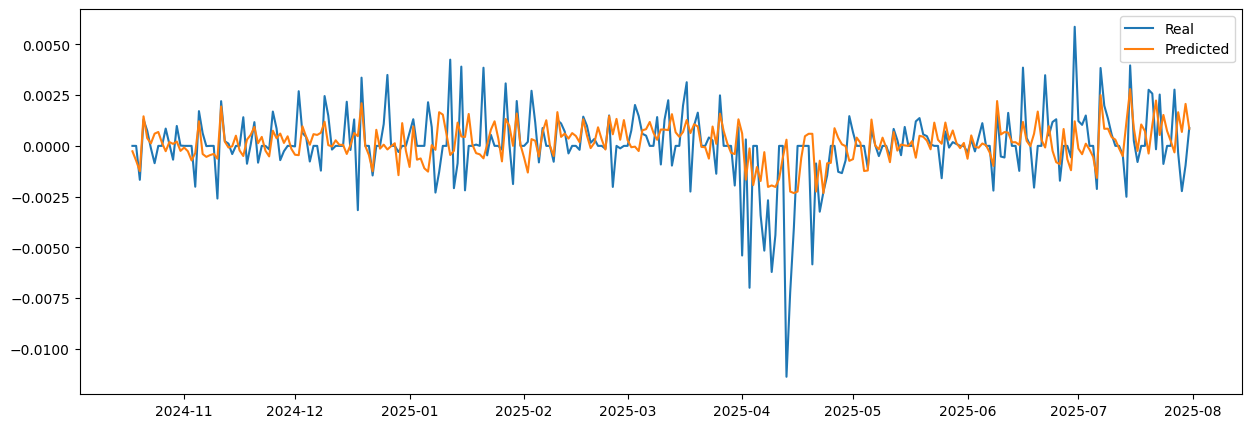

In [ ]:
# Graph Precited vs Real
plt.figure(figsize=(15, 5))
plt.plot(y_test.index, y_test.values, label="Real")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.legend()
plt.show()

In [ ]:
# Make table with Predicted vs Real
df_predictions = pd.DataFrame({
    "fecha": y.loc[y_test.index].index,
    "real_variation": y_test.values,
    "pred_variation": y_pred
})

# First known nominal value
first_test_nominal_value = (
    df_master.loc[
        df_master["fecha"] == df_predictions["fecha"].min(),
        "compra_dolar"
    ]
    .iloc[0]
)

# Reconstruct nominal values
df_predictions["real_nominal"] = (
    (1 + df_predictions["real_variation"])
    .cumprod()
    * first_test_nominal_value
)

df_predictions["pred_nominal"] = (
    df_predictions["real_nominal"].shift(1)
    * (1 + df_predictions["pred_variation"])
)

# First prediction starts from the last known value before the test set
df_predictions.loc[df_predictions.index[0], "pred_nominal"] = (
    first_test_nominal_value
    * (1 + df_predictions.loc[df_predictions.index[0], "pred_variation"])
)

df_predictions

,fecha,real_variation,pred_variation,real_nominal,pred_nominal
0,2024-10-18,0.000000,-0.000267,60.0107,59.994676
1,2024-10-19,0.000000,-0.000728,60.0107,59.966984
2,2024-10-20,-0.001671,-0.001247,59.9104,59.935893
3,2024-10-21,0.001299,0.001456,59.9882,59.997618
4,2024-10-22,0.000745,0.000378,60.0329,60.010860
...,...,...,...,...,...
282,2025-07-27,0.002770,-0.000322,60.7501,60.562801
283,2025-07-28,-0.000362,0.001657,60.7281,60.850777
284,2025-07-29,-0.002228,0.000687,60.5928,60.769816
285,2025-07-30,-0.000954,0.002067,60.5350,60.718052


In [ ]:
df_predictions["position"] = np.where(
    df_predictions["pred_variation"] > 0,
    1,      # Buy USD
    0       # Stay in DOP
)

df_predictions["strategy_return"] = (
    df_predictions["position"]
    * df_predictions["real_variation"]
)
df_predictions

,fecha,real_variation,pred_variation,real_nominal,pred_nominal,position,strategy_return
0,2024-10-18,0.000000,-0.000267,60.0107,59.994676,0,0.000000
1,2024-10-19,0.000000,-0.000728,60.0107,59.966984,0,0.000000
2,2024-10-20,-0.001671,-0.001247,59.9104,59.935893,0,-0.000000
3,2024-10-21,0.001299,0.001456,59.9882,59.997618,1,0.001299
4,2024-10-22,0.000745,0.000378,60.0329,60.010860,1,0.000745
...,...,...,...,...,...,...,...
282,2025-07-27,0.002770,-0.000322,60.7501,60.562801,0,0.000000
283,2025-07-28,-0.000362,0.001657,60.7281,60.850777,1,-0.000362
284,2025-07-29,-0.002228,0.000687,60.5928,60.769816,1,-0.002228
285,2025-07-30,-0.000954,0.002067,60.5350,60.718052,1,-0.000954


In [ ]:
print("Avg. strategy return:", df_predictions["strategy_return"].mean())

Avg. strategy return: 0.0001421808806539921


### Resumen del desempeño del modelo

El modelo presenta **una capacidad predictiva limitada** para pronosticar la variación mensual del tipo de cambio USD/DOP.

- **R² = 0.08**: El modelo explica aproximadamente **el 8% de la variabilidad** en las variaciones mensuales del tipo de cambio, lo que indica que la mayor parte de la dinámica permanece sin explicar.
- **Precisión direccional = 54%**: El modelo acierta la dirección del movimiento del tipo de cambio ligeramente por encima del azar (≈50%), lo que sugiere la existencia de una señal predictiva débil.
- **Retorno promedio de la estrategia = 0.014% mensual**: Una estrategia de compra de dólares basada en las predicciones del modelo genera un retorno promedio muy reducido, insuficiente para compensar los costos de transacción que existirían en un escenario real (por ejemplo, spreads o comisiones).

En conjunto, los resultados indican que el modelo logra capturar **una señal estadística débil**, pero **su capacidad predictiva no es suficiente para sustentar una estrategia de inversión rentable** bajo el esquema evaluado. Mejoras futuras podrían requerir la incorporación de variables explicativas adicionales, un refinamiento de la variable objetivo o la evaluación de enfoques de modelado alternativos.